<a href="https://colab.research.google.com/github/crreyes-unal/Reporte-problemas-MpAM/blob/main/Ejercicio12_Juntura_Red_Shallow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***¿Cuál es el origen de las junturas en una red neuronal shallow?***

En una red neuronal superficial con funciones de activación lineales a trozos, las junturas en la función de salida se originan en el punto donde la activación de cada neurona oculta se hace cero.

Sea una red shallow con entrada escalar $x$ y una capa oculta con neuronas activadas mediante $\text{ReLU}(a) = \max(0, a)$. Para la neurona oculta $i$, su activación $a_i$ está dada por $a_i(x) = \theta_{0i} + \theta_{1i} x$. Por tanto, la activación de la neurona es
$$h_i(x) = \text{ReLU}(\theta_{0i} + \theta_{1i} x) = \max(0, \theta_{0i} + \theta_{1i} x)$$

La función $\text{ReLU}$ cambia de pendiente de, $0$ a $1$, en el punto donde su argumento es cero. Por lo tanto, la juntura producida por la neurona $i$ ocurre en la posición $x_{\text{j}}$ tal que

$$\theta_{0i} + \theta_{1i} x_{\text{j}} = 0 \text{ así } x_{\text{j}} = -\frac{\theta_{0i}}{\theta_{1i}}$$

La salida de la red es una combinación lineal de las activaciones ponderadas por pesos $\phi_i$ y un sesgo final $\phi_0$, esto es, $y = \phi_0 + \sum_{i=1}^{D} \phi_i h_i(x)$.

*Podemos ver lo anterior gráficamente como sigue*

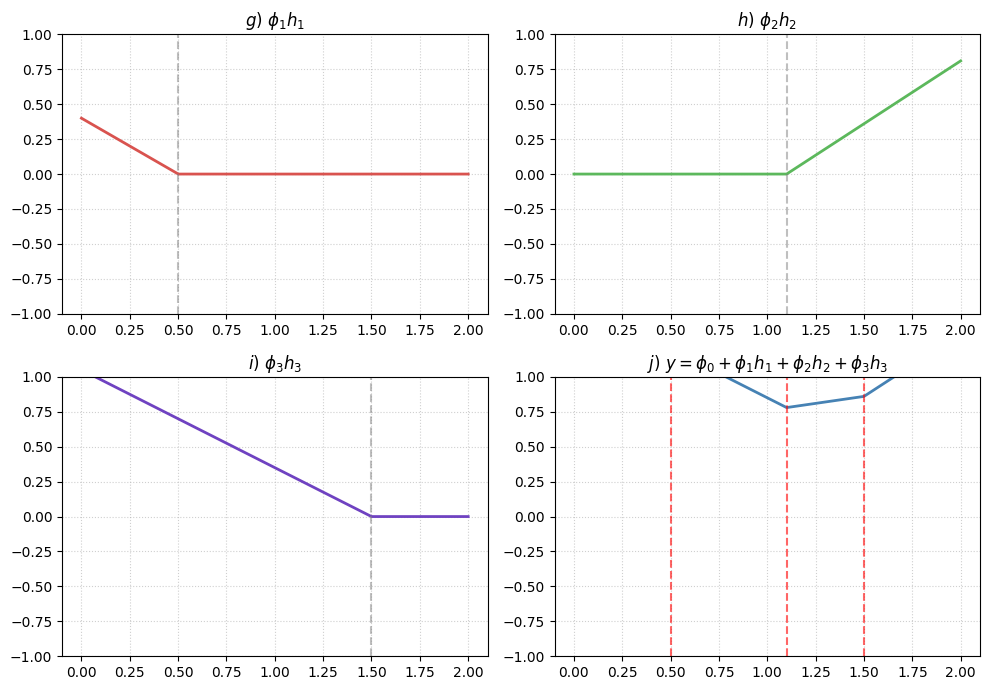

Juntura de la neurona 1 ocurre en x = 0.50
Juntura de la neurona 2 ocurre en x = 1.10
Juntura de la neurona 3 ocurre en x = 1.50


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0, x)

# Dominio de entrada
x = np.linspace(0.0, 2.0, 500)

# Parámetros capa oculta bias theta_0 y peso theta_1
theta = [
    (0.5, -1.0),   # Juntura en x = 0.5
    (-1.1, 1.0),   # Juntura en x = 1.1
    (1.5, -1.0)    # Juntura en x = 1.5
]

# Pesos de la capa de salida phi_i y sesgo final phi_0
phi_weights = [0.8, 0.9, 0.7]
phi_0 = 0.5

# Cálculo de activaciones ponderadas
h1 = phi_weights[0] * relu(theta[0][0] + theta[0][1] * x)
h2 = phi_weights[1] * relu(theta[1][0] + theta[1][1] * x)
h3 = phi_weights[2] * relu(theta[2][0] + theta[2][1] * x)

# Salida combinada
y = phi_0 + h1 + h2 + h3

# Calcular la posición exacta de cada juntura
joints = [-t[0] / t[1] for t in theta]

# Grafica
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

# Gráfica g
axes[0, 0].plot(x, h1, color='#d9534f', linewidth=2)
axes[0, 0].set_title(r'$g)\ \phi_1 h_1$')
axes[0, 0].set_ylim(-1.0, 1.0)
axes[0, 0].axvline(joints[0], color='gray', linestyle='--', alpha=0.5)
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Gráfica h
axes[0, 1].plot(x, h2, color='#5cb85c', linewidth=2)
axes[0, 1].set_title(r'$h)\ \phi_2 h_2$')
axes[0, 1].set_ylim(-1.0, 1.0)
axes[0, 1].axvline(joints[1], color='gray', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# Gráfica i
axes[1, 0].plot(x, h3, color='#6f42c1', linewidth=2)
axes[1, 0].set_title(r'$i)\ \phi_3 h_3$')
axes[1, 0].set_ylim(-1.0, 1.0)
axes[1, 0].axvline(joints[2], color='gray', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# Gráfica j
axes[1, 1].plot(x, y, color='#4682b4', linewidth=2)
axes[1, 1].set_title(r'$j)\ y = \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3$')
axes[1, 1].set_ylim(-1.0, 1.0)
for j in joints:
    axes[1, 1].axvline(j, color='red', linestyle='--', alpha=0.6)
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#Texto de salida
for idx, j_pos in enumerate(joints, 1):
    print(f"Juntura de la neurona {idx} ocurre en x = {j_pos:.2f}")